In [18]:
from datasets import load_dataset

import numpy as np
import torch
import matplotlib.pyplot as plt
from configurations.plot_config import set_font_sizes, apply_general_styles, create_fig, FONTSIZES, convert_number
from configurations.data_config import make_params_dict , load_data, save_fig, save_data
from matplotlib.gridspec import GridSpec

from attention_nn.dataset import get_all_sentences, build_tokenizer, get_dataloader, get_random_dataloader
from attention_nn.model import create_model

apply_general_styles()

# Bigram

In [5]:
# Define configuration
config = {
    'dataset_size': 10000,
    'train_fraction': 0.9,
    'batch_size': 1,
    'L': 128,
    'datasource': 'roneneldan/TinyStories',
}

# Prepare data loaders and tokenizer
print('Preparing data loaders...')
train_dataloader, val_dataloader , tokenizer = get_dataloader(config)
vocab_size = tokenizer.get_vocab_size()
print(f'Vocabulary size = {vocab_size}. Maximum entropy per token = {np.log(vocab_size):.4f} nats.')
pad_id = tokenizer.token_to_id("[PAD]")


Preparing data loaders...


Min sequence length = 53
Max sequence length = 1040
Vocabulary size = 8043. Maximum entropy per token = 8.9926 nats.


In [6]:
# Measure token frequency in all dataset for each position in sequence
data_stats = {}
token_counts = np.zeros((config['L'], vocab_size))

for batch in train_dataloader:
    input = batch['input'][0].numpy() # (seq_len,)
    token_counts[np.arange(config['L']), input] += 1
for batch in val_dataloader:
    input = batch['input'][0].numpy() # (seq_len,)
    token_counts[np.arange(config['L']), input] += 1

# Eliminate data from padding tokens
token_counts[:, pad_id] = 0
data_stats['unsorted_token_counts'] = token_counts.copy()

total_counts = token_counts.sum(axis=0)  # (vocab_size,)
sorted_tokens = np.argsort(-total_counts)  # Indices of tokens sorted by frequency descending
token_counts = token_counts[:, sorted_tokens]  # Sort token counts accordingly
total_counts = total_counts[sorted_tokens]

# Compute entropy per position
token_frequencies = token_counts / token_counts.sum(axis=1, keepdims=True)  # (L, vocab_size)
entropies = -np.nansum(token_frequencies * np.log(token_frequencies + 1e-12), axis=1)  # (L,)

# Compute total entropy
total_token_frequencies = total_counts / total_counts.sum()
total_entropy = -np.nansum(total_token_frequencies * np.log(total_token_frequencies + 1e-12))

data_stats['sorted_token_counts'] = token_counts.copy()
data_stats['sorted_tokens'] = sorted_tokens
data_stats['entropies_per_position'] = entropies
data_stats['total_entropy'] = total_entropy
data_stats['sorted_rank'] = np.argsort(sorted_tokens)


In [7]:
# Compute the bigram distribution of tokens in the training set
print('Computing bigram distribution...')
bigram = np.zeros((vocab_size, vocab_size))  # Initialize with zeros
total_bigrams = 0
for batch in train_dataloader:
    input_ids = batch['input'].squeeze(0).numpy()  # Remove batch dimension
    # Iterate through the sequence to count bigrams
    for i in range(len(input_ids) - 1):
        token1 = input_ids[i]
        token2 = input_ids[i + 1]
        if token1 != pad_id or token2 != pad_id:
            bigram[token1, token2] += 1
            total_bigrams += 1

for batch in val_dataloader:
    input_ids = batch['input'].squeeze(0).numpy()  # Remove batch dimension
    # Iterate through the sequence to count bigrams
    for i in range(len(input_ids) - 1):
        token1 = input_ids[i]
        token2 = input_ids[i + 1]
        if token1 != pad_id or token2 != pad_id:
            bigram[token1, token2] += 1
            total_bigrams += 1

bigram /= total_bigrams  # Normalize to get probabilities

# Conditional bigram distribution P(token2 | token1)
normalization = bigram.sum(axis=1, keepdims=True)
# To avoid division by zero, set zero rows to one before division
normalization[normalization == 0] = 1
conditional_bigram = bigram / normalization

data_stats['bigram'] = bigram
data_stats['unigram'] = bigram.sum(axis=1)
data_stats['conditional_bigram'] = conditional_bigram
data_stats['bigram_entropy'] = -np.nansum(bigram * np.log(bigram + 1e-12))

for key, value in data_stats.items():
    print(f'{key}: {value.shape}')

names = ['dataset_size','L']
params = {k: config[k] for k in names}
save_data(data_stats,'token_details','data_statistics',params=params,base_dir='../data')

Computing bigram distribution...
unsorted_token_counts: (128, 8043)
sorted_token_counts: (128, 8043)
sorted_tokens: (8043,)
entropies_per_position: (128,)
total_entropy: ()
sorted_rank: (8043,)
bigram: (8043, 8043)
unigram: (8043,)
conditional_bigram: (8043, 8043)
bigram_entropy: ()
File saved with pickle.dump on /u/c/cerazova/Transformers/data/data_statistics as token_details_L128_dataset_size10000.pkl


# Measures

In [12]:
# Fixed Model Parameters
d = 512
dataset_size = 10000
L = 128
rank = None
batch_size = 64
num_epochs = 10

# Architectural Parameters
skip_residual = False
fr_emb = False
fr_att = False

# Hyperparameters
beta = 1.0
lr = 0.05

# Load data statistics
params = {'dataset_size': dataset_size, 'L': L}
data_stats = load_data('token_details','data_statistics',params=params,base_dir='../data')
total_entropy = data_stats['total_entropy']
entropies = data_stats['entropies_per_position']
total_token_frequencies = data_stats['sorted_token_counts']/data_stats['sorted_token_counts'].sum()
entropy_unigram = data_stats['total_entropy']
entropy_bigram = data_stats['bigram_entropy']


# Loop over various configurations  =  amp, type_enc,  unmb
sigma = 0.5
amp = 1.0
type_enc = 'learned'
unmb = True


fix_names = ['rank','d','L','dataset_size','skip_residual','fr_att','fr_emb','batch_size','lr','beta']
var_names = ['type_enc','amp','unmb','sigma']
params = make_params_dict(fix_names , var_names)


summary_scalar = load_data('summary_log',experiment_name='new_evolution_scalar', params=params)
summary_matrices = load_data('summary_log',experiment_name='new_evolution_matrices', params=params)


print('In scalar summary:')
for key in summary_scalar.keys():
    if key != 'embedd_top_tokens':
        print(f'{key}: {summary_scalar[key].shape}')

# summary_scalar['KL_M_bigram'] *= -1
bs = batch_size
n = dataset_size

File token_details_L128_dataset_size10000.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/data_statistics
File summary_log_amp1_sigma0.5_type_enclearned_unmbTrue.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_evolution_scalar/L128_batch_size64_beta1_d512_dataset_size10000_fr_attFalse_fr_embFalse_lr0.05_rankNone_skip_residualFalse
File summary_log_amp1_sigma0.5_type_enclearned_unmbTrue.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_evolution_matrices/L128_batch_size64_beta1_d512_dataset_size10000_fr_attFalse_fr_embFalse_lr0.05_rankNone_skip_residualFalse
In scalar summary:
evaluation_steps: (166,)
train_loss: (166,)
val_loss: (166,)
entropy: (166, 5)
part_ratio: (166, 5)
pos_attended: (166, 5)
pred_entropy: (166, 128)
att_in_fractions: (166, 5, 128)
KL_uniform: (166,)
KL_tot: (166,)
KL_mu: (166,)
KL_bigram: (166,)
KL_M_bigram: (166,)
KL_M_model: (166,)
average_rank: (166, 5)
embedd_eigvals: (166, 512)
embedd_mean: (166,)
embed

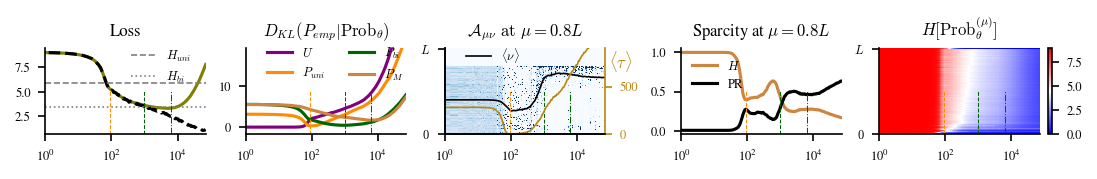

In [13]:
# Setup and variables
step_scalar = summary_scalar['evaluation_steps']
vocab_size = int(summary_scalar['vocab_size'])
sequence_fractions = summary_scalar['sequence_fractions']
i_seq_frac = 3
f = sequence_fractions[i_seq_frac]
idx_uni = np.argmin(summary_scalar['KL_tot'])
idx_bigram = np.argmin(summary_scalar['KL_bigram'])
idx_M_bigram = np.argmin(summary_scalar['KL_M_bigram'])

summary_scalar['PR_f'] = summary_scalar['part_ratio'][:,i_seq_frac]
summary_scalar['H_f'] = summary_scalar['entropy'][:,i_seq_frac]
summary_scalar['pos_attnd'] = L*f*summary_scalar['pos_attended'][:,i_seq_frac]
summary_scalar['av_rnk'] = summary_scalar['average_rank'][:, i_seq_frac]
summary_scalar['att_pattern'] = summary_scalar['att_in_fractions'][:,i_seq_frac]
seq_range = np.arange(0, L)
# plt.rcParams['text.usetex'] = False

col_unig = 'darkorange'
col_bigr = 'darkgreen'
col_M_bigr = 'peru'

lines_plots = {
    'Loss': [{'var':'val_loss','color':'olive','ls':'-','label':''},
             {'var':'train_loss','color':'k','ls':'--','label':''}],  
    r'$D_{KL}(P_{emp}|\text{Prob}_\theta)$': [{'var':'KL_uniform','color':'purple','ls':'-', 'label':r'$U$'},
                       {'var':'KL_tot','color':col_unig,'ls':'-','label':r'$P_{uni}$'},
                       {'var':'KL_bigram','color':col_bigr,'ls':'-','label':r'$P_{bi}$'} , 
                       {'var':'KL_M_bigram','color':col_M_bigr,'ls':'-','label':r'$P_{M}$'}],
    rf'$\mathcal{{A}}_{{\mu \nu}} \text{{ at }} {{\mu = {f}L}}$': [
                                        {'var': 'pos_attnd', 'color': 'k', 'ls': '-', 'label': r'$\langle \nu \rangle$','lw':0.8},
                                        {'var': 'av_rnk', 'color': 'darkgoldenrod', 'ls': '-', 'label': r'$\langle \tau \rangle$','lw':0.8},
    ],
    fr'Sparcity at ${{\mu = {f}L}}$': [{'var':'H_f','color':'peru','ls':'-','label':r'$H$'},
                                      {'var':'PR_f','color':'k','ls':'-','label':'PR'} ],
}

img_plots = {
        rf'$\mathcal{{A}}_{{\mu \nu}} \text{{ at }} {{\mu = {f}L}}$': {'matrix':'att_pattern','cmap':'Blues','vmin':None,'vmax':0.04,'colorbar':False},
        r'$H[\text{Prob}_\theta^{(\mu)}]$' : {'matrix':'pred_entropy','cmap':'bwr','vmin':None,'vmax':None,'colorbar':True},
}

leg_config = [
    {'ncols':1,'loc':(0.5,0.52)},
    {'ncols':2,'loc':(0.1,0.55)},
    {'ncols':1,'loc':(0.1,0.75)},
    {'ncols':1,'loc':'best'},

]

idx_lines = [0,1,2,3]
idx_img = [2,4]
set_font_sizes(conf='tight')


# Create figure
fig , axes = create_fig(nrows=1,ncols=5,size='double',h=0.15)


# Plot lines
for i , title in enumerate(lines_plots.keys()):
    ax = axes[idx_lines[i]]
    ax.set_title(title, fontsize=FONTSIZES['s'])
    for setting in lines_plots[title]:
        conf = {key: setting[key] for key in setting.keys() - {'var'}}
        if setting['var'] == 'av_rnk':
            ax2 = ax.twinx()
            ax2.spines['right'].set_visible(True)
            ax2.spines['right'].set_color(setting['color'])
            ax2.tick_params(axis='y', colors=setting['color'])
            ax2.set_ylabel(r'$\langle\tau\rangle$', color=setting['color'], loc='top' ,labelpad=-3, rotation=0, fontsize=FONTSIZES['s'])
            ax = ax2
        ax.plot('evaluation_steps',setting['var'],data=summary_scalar, **conf)


# Plot images
for i , title in enumerate(img_plots.keys()):
    ax = axes[idx_img[i]]
    ax.set_title(title, fontsize=FONTSIZES['s'])
    ax.set_yticks([0,L-1],[r'$0$',r'$L$'])
    setting = img_plots[title]
    matrix = summary_scalar[setting['matrix']]
    conf = {key: setting[key] for key in setting.keys() - {'matrix','colorbar'}}
    mesh = ax.pcolormesh(step_scalar,seq_range, matrix.T, **conf)
    if setting['colorbar']:
        cbar = fig.colorbar(mesh, ax=ax)
        cbar.ax.tick_params(labelsize=FONTSIZES['xs'])

for l , ls, lbl in zip([entropy_unigram, entropy_bigram-entropy_unigram],['--',':'], [r'$H_{uni}$',r'$H_{bi}$']):
    axes[0].axhline(l, color='gray', ls=ls, lw=0.8, label=lbl)

for i , ax in enumerate(axes):
    ax.axvline(step_scalar[idx_uni], ymax=0.5,color=col_unig, ls='--', lw=0.5)
    ax.axvline(step_scalar[idx_bigram], ymax = 0.5,color=col_bigr, ls='--', lw=0.5)
    ax.axvline(step_scalar[idx_M_bigram], ymax = 0.5,color=col_bigr, ls='-.', lw=0.5)
    ax.set_xscale('log')
    ax.tick_params(axis='x', which='minor',  bottom=False)
    # Plot legend only if there are lines to show
    if i != 4:
        ax.legend(frameon=False,**leg_config[i])

ax2.set_ylim(bottom=0,top=900)
axes[1].set_ylim(top=19)
axes[0].set_xlim(left=1)

names = ['d','n','L','bs','lr','type_enc','sigma','amp','unmb']
params = make_params_dict(names)
# save_fig(fig,'new_training_curve_with_M',params=params,date=True)


# Different metrics

In [8]:
# Fixed Model Parameters
d = 512
dataset_size = 10000
L = 128
rank = None
batch_size = 64
num_epochs = 10

# Architectural Parameters
skip_residual = False
fr_emb = False
fr_att = False

# Hyperparameters
beta = 1.0
lr = 0.05

# Load data statistics
params = {'dataset_size': dataset_size, 'L': L}
data_stats = load_data('token_details','data_statistics',params=params,base_dir='../data')
total_entropy = data_stats['total_entropy']
entropies = data_stats['entropies_per_position']
total_token_frequencies = data_stats['sorted_token_counts']/data_stats['sorted_token_counts'].sum()
entropy_unigram = data_stats['total_entropy']
entropy_bigram = data_stats['bigram_entropy']


# Loop over various configurations  =  amp, type_enc,  unmb
sigma = 0.5
amp = 1.0
type_enc = 'learned'
unmb = True


fix_names = ['rank','d','L','dataset_size','skip_residual','fr_att','fr_emb','batch_size','lr','beta']
var_names = ['type_enc','amp','unmb','sigma']
params = make_params_dict(fix_names , var_names)


summary_scalar = load_data('summary_log',experiment_name='new_evolution_scalar', params=params)
summary_matrices = load_data('summary_log',experiment_name='new_evolution_matrices', params=params)


print('In scalar summary:')
for key in summary_scalar.keys():
    if key != 'embedd_top_tokens':
        print(f'{key}: {summary_scalar[key].shape}')

# summary_scalar['KL_M_bigram'] *= -1
bs = batch_size
n = dataset_size

File token_details_L128_dataset_size10000.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/data_statistics
File summary_log_amp1_sigma0.5_type_enclearned_unmbTrue.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_evolution_scalar/L128_batch_size64_beta1_d512_dataset_size10000_fr_attFalse_fr_embFalse_lr0.05_rankNone_skip_residualFalse
File summary_log_amp1_sigma0.5_type_enclearned_unmbTrue.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_evolution_matrices/L128_batch_size64_beta1_d512_dataset_size10000_fr_attFalse_fr_embFalse_lr0.05_rankNone_skip_residualFalse
In scalar summary:
evaluation_steps: (166,)
train_loss: (166,)
val_loss: (166,)
entropy: (166, 5)
part_ratio: (166, 5)
pos_attended: (166, 5)
pred_entropy: (166, 128)
att_in_fractions: (166, 5, 128)
KL_uniform: (166,)
KL_tot: (166,)
KL_mu: (166,)
KL_bigram: (166,)
KL_M_bigram: (166,)
KL_M_model: (166,)
average_rank: (166, 5)
embedd_eigvals: (166, 512)
embedd_mean: (166,)
embed

Figure saved on /u/c/cerazova/Transformers/plots/2026-02 as new_summary_scalars_L128_amp1_bs64_d512_lr0.05_n10000_sigma0.5_type_enclearned_unmbTrue.png


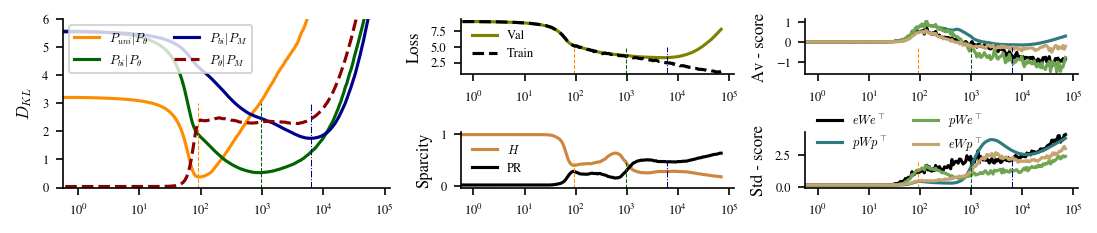

In [76]:
# Setup and variables 
step_scalar = summary_scalar['evaluation_steps']
vocab_size = int(summary_scalar['vocab_size'])
sequence_fractions = summary_scalar['sequence_fractions']
i_seq_frac = 3
f = sequence_fractions[i_seq_frac]
idx_uni = np.argmin(summary_scalar['KL_tot'])
idx_bigram = np.argmin(summary_scalar['KL_bigram'])
idx_M_bigram = np.argmin(summary_scalar['KL_M_bigram'])
idx_M_model = np.argmin(summary_scalar['KL_M_model'])

summary_scalar['PR_f'] = summary_scalar['part_ratio'][:,i_seq_frac]
summary_scalar['H_f'] = summary_scalar['entropy'][:,i_seq_frac]

labels = [r'$eWe^\top$', r'$pWp^\top$', r'$pWe^\top$', r'$eWp^\top$']
colors = plt.get_cmap('gist_earth')(np.linspace(0.,0.8,4))



col_unig = 'darkorange'
col_bigr = 'darkgreen'
col_m_bigr = 'darkblue'
col_m_model = 'darkred'

lines_plots = {
    r'$D_{KL}$': [
                       {'var':'KL_uniform','color':'purple','ls':'-', 'label':r'$U$'},
                       {'var':'KL_tot','color':col_unig,'ls':'-','label':r'$P_{uni} | P_\theta$'},
                       {'var':'KL_bigram','color':col_bigr,'ls':'-','label':r'$P_{bi} | P_\theta$'},
                       {'var':'KL_M_bigram','color':col_m_bigr,'ls':'-','label':r'$P_{bi} | P_{M}$'},
                       {'var':'KL_M_model','color':col_m_model,'ls':'--','label':r'$P_{\theta} | P_{M}$'} ][1:],
    'Loss': [{'var':'val_loss','color':'olive','ls':'-','label':'Val'},
             {'var':'train_loss','color':'k','ls':'--','label':'Train'}], 
    fr'Sparcity': [{'var':'H_f','color':'peru','ls':'-','label':r'$H$'},
                                      {'var':'PR_f','color':'k','ls':'-','label':'PR'} ],
}

leg_config = [
    {'ncols':2,'loc':'upper left'},
    {'ncols':1,'loc':'best','frameon':False},
    {'ncols':1,'loc':'best','frameon':False}, None, None]

set_font_sizes(conf='tight')
w = 1.0
h = 0.2

double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column
width = double_w
figsize = (w*width,h*width)
# Create figure
# fig , axes = create_fig(nrows=1,ncols=5,size='double',h=0.15)
fig = plt.figure(layout="constrained",figsize=figsize)
gs = GridSpec(2,3, figure=fig, width_ratios=[1.2,1,1], height_ratios=[1,1])#, wspace=0.15, hspace=0.15)

axes = [fig.add_subplot(gs[:,0]), 
        fig.add_subplot(gs[0,1]), fig.add_subplot(gs[1,1]),
        fig.add_subplot(gs[0,2]), fig.add_subplot(gs[1,2])]
# Plot lines
for i , title in enumerate(lines_plots.keys()):
    ax = axes[i]
    ax.set_ylabel(title, fontsize=FONTSIZES['s'])
    for setting in lines_plots[title]:
        conf = {key: setting[key] for key in setting.keys() - {'var'}}
        ax.plot('evaluation_steps',setting['var'],data=summary_scalar, **conf)


for i , key in enumerate(['S_stds','S_means']):
    ax = axes[-i-1]
    ax.set_ylabel([r'Std - score',r'Av - score'][i], fontsize=FONTSIZES['s'])
    for i , lb in enumerate(labels):
        ax.plot(step_scalar, summary_scalar[key][:,i], label=lb,color=colors[i])

axes[0].set_ylim(bottom=0,top=6)

for i , conf in enumerate(leg_config):
    ax = axes[i]
    ax.axvline(step_scalar[idx_uni], ymax=0.5,color=col_unig, ls='--', lw=0.5)
    ax.axvline(step_scalar[idx_bigram], ymax = 0.5,color=col_bigr, ls='--', lw=0.5)
    ax.axvline(step_scalar[idx_M_bigram], ymax = 0.5,color=col_m_bigr, ls='-.', lw=0.5)
    # ax.axvline(step_scalar[idx_M_model], ymax = 0.5,color=col_m_model, ls='--', lw=0.5)
    ax.set_xscale('log')
    ax.tick_params(axis='x', which='minor',  bottom=False)
    # Plot legend only if there are lines to show
    if conf is not None:
        ax.legend(fontsize=FONTSIZES['xs'],**conf)

# Take the labels of the last axis and put them in the figure
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.74,0.32), ncol=2, frameon=False, fontsize=FONTSIZES['xs'])

names = ['d','n','L','bs','lr','type_enc','sigma','amp','unmb']
params = make_params_dict(names)
save_fig(fig,'new_summary_scalars',params=params,date=True)

# Evolution P and E contribution to scores

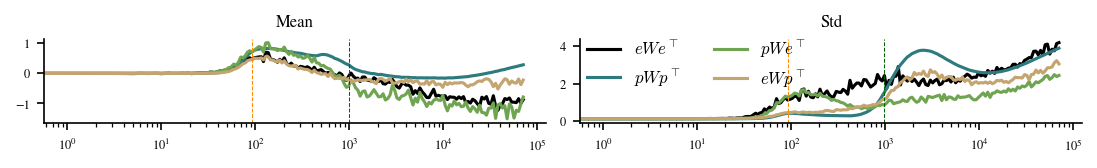

In [17]:
# Settings
# [See, Spp, Spq, Sqp]
# labels = [r'$S^{(e,e)}$', r'$S^{(p,p)}$', r'$S^{(p,e)}$', r'$S^{(e,p)}$']
labels = [r'$eWe^\top$', r'$pWp^\top$', r'$pWe^\top$', r'$eWp^\top$']
colors = plt.get_cmap('gist_earth')(np.linspace(0.,0.8,4))

set_font_sizes(conf='tight')
#Plots
fig , axes = create_fig(nrows=1,ncols=2,size='double',h=0.14)

ax = axes[0]
for i , lb in enumerate(labels):
    ax.plot(step_scalar, summary_scalar['S_means'][:,i], label=lb,color=colors[i])
ax.set_title(r'Mean', fontsize=FONTSIZES['s'])

ax = axes[1]
for i , lb in enumerate(labels):
    ax.plot(step_scalar, summary_scalar['S_stds'][:,i], label=lb,color=colors[i])
ax.set_title(r'Std', fontsize=FONTSIZES['s'])
ax.set_xscale('log')
ax.legend(frameon=False,ncols=2,fontsize=FONTSIZES['s'],loc=(0.,0.32))
# ax.set_yscale('log')
for ax in axes:
    ax.axvline(step_scalar[idx_uni], ymax=1,color=col_unig, ls='--', lw=0.5)
    ax.axvline(step_scalar[idx_bigram], ymax = 1,color=col_bigr, ls='--', lw=0.5)
    # ax.axvline(step_scalar[idx_M_bigram], ymax = 1,color=col_M_bigr, ls='-.', lw=0.5)

names = ['d','n','L','bs','lr','type_enc','sigma','amp','unmb']
params = make_params_dict(names)
# save_fig(fig,'attention_contributions',params=params,date=True)


In [80]:
idxes = np.array([0,5,7,9,11,13,15,17,19,21,23])
summary_matrices['matrix_steps'][idxes]

array([    0,    11,    29,    77,   205,   544,  1440,  3809, 10075,
       26652, 70499])

In [86]:
get_every = 2
i_batch = 0
idxes = np.array([0,7,10,11,14,17,20,23])
matrix_results = {
    'steps' : summary_matrices['matrix_steps'][idxes],
    'x' : summary_matrices['x'][idxes][:,i_batch,:],
    'e' : summary_matrices['e'][idxes][:,i_batch,:],
    'W' : summary_matrices['W'][idxes],
}
matrix_results['p'] = matrix_results['x'] - matrix_results['e']
matrix_results['See'] =  matrix_results['e'] @ matrix_results['W'] @ matrix_results['e'].transpose(0,2,1) / d
matrix_results['Spp'] =  matrix_results['p'] @ matrix_results['W'] @ matrix_results['p'].transpose(0,2,1) / d
matrix_results['Spe'] =  matrix_results['p'] @ matrix_results['W'] @ matrix_results['e'].transpose(0,2,1) / d
matrix_results['Sep'] =  matrix_results['e'] @ matrix_results['W'] @ matrix_results['p'].transpose(0,2,1) / d
for key in matrix_results.keys():
    print(f'{key} : {matrix_results[key].shape}')

steps : (8,)
x : (8, 128, 512)
e : (8, 128, 512)
W : (8, 512, 512)
p : (8, 128, 512)
See : (8, 128, 128)
Spp : (8, 128, 128)
Spe : (8, 128, 128)
Sep : (8, 128, 128)


/tmp/ipykernel_2634308/1436050257.py:5: RuntimeWarning: divide by zero encountered in log10
  titles = [rf'$10^{{{np.log10(step):.2}}}$' for step in matrix_steps]


Figure saved on /u/c/cerazova/Transformers/plots/2026-02 as matrix_attention_contributions_L128_amp1_bs64_d512_lr0.05_n10000_sigma0.5_type_enclearned_unmbTrue.png


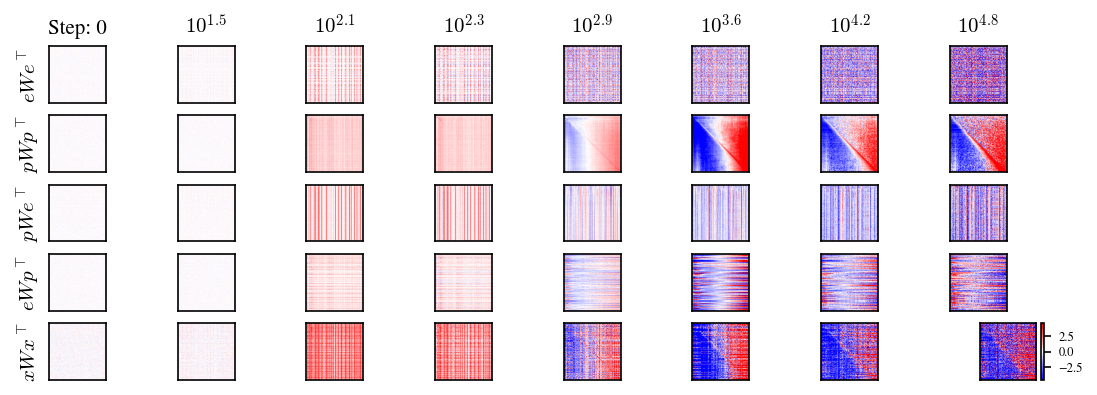

In [88]:
# Settings
matrix_steps = matrix_results['steps']
ncols = len(matrix_steps)
nrows = 4
titles = [rf'$10^{{{np.log10(step):.2}}}$' for step in matrix_steps]
labels = [r'$eWe^\top$', r'$pWp^\top$', r'$pWe^\top$', r'$eWp^\top$']
cmap = 'bwr'
set_font_sizes(conf='tight')

# Make plots
fig , axes = create_fig(nrows=nrows+1,ncols=ncols,size='double',h=0.35)

for i , tit in enumerate(titles):
    scores = [matrix_results[key] for key in ['See','Spp','Spe','Sep']]
    for j ,lb in enumerate(labels):
        ax = axes[j,i]
        # ax.set_axis_off()
        ax.spines[['left','bottom','top','right']].set_visible(True)
        ax.tick_params(axis='both',left=False,bottom=False)
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0: ax.set_title(f'Step: 0' if i == 0 else tit)
        if i == 0: ax.set_ylabel(lb)
        S = scores[j][i]
        ax.imshow(S,cmap=cmap,vmin=-4.5,vmax=4.5)
score_total = sum(matrix_results[key] for key in ['See','Spp','Spe','Sep'])
for i , _ in enumerate(titles):
    ax = axes[nrows,i]
    ax.spines[['left','bottom','top','right']].set_visible(True)
    ax.tick_params(axis='both',left=False,bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])
    if i == 0: ax.set_ylabel(r'$xWx^\top$')
    
    ax.imshow(score_total[i],cmap=cmap,vmin=-4.5,vmax=4.5)

    if i == ncols-1:
        plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
    

# Add small colorbar at the last plot
# plt.colorbar(im,cax=ax,fraction=0.1,shrink=0.1)
names = ['d','n','L','bs','lr','type_enc','sigma','amp','unmb']
params = make_params_dict(names)
save_fig(fig,'matrix_attention_contributions',params=params,date=True)


# Eigenvalues of EU

In [25]:
np.log10(summary_matrices['matrix_steps'][-1])

np.float64(4.848182956742292)

In [89]:
get_every = 2
i_batch = 0
idxes = np.array([0,7,10,11,14,17,20,23])
embedd_results = {
    'steps' : summary_matrices['matrix_steps'][idxes],
    'E' : summary_matrices['embeddings'][idxes],
    'U' : summary_matrices['U'][idxes]
}

for key in embedd_results.keys():
    print(f'{key} : {embedd_results[key].shape}')

embedd_results['eigenvals'] = []

for i , _ in enumerate(embedd_results['steps']):
    E = torch.tensor(embedd_results['E'][i],device='cuda') # (V,d)
    U = torch.tensor(embedd_results['U'][i],device='cuda') # (d,V)
    print(E.shape, U.shape)
    cov = E  @ U / d # (V,V)
    eigvals = torch.linalg.eigvals(cov).cpu().numpy() # (V,)
    embedd_results['eigenvals'].append(eigvals)
   
embedd_results['eigenvals'] = np.array(embedd_results['eigenvals']) # (steps, V)

for key in embedd_results.keys():
    print(f'{key} : {embedd_results[key].shape}')
# e : (23, 3, 128, 512)
# embeddings : (23, 8043, 512)
# embedd_grad_norms : (23, 8043)
# W : (23, 512, 512)
# p : (23, 1, 128, 512)
# U : (23, 512, 8043)

steps : (8,)
E : (8, 8043, 512)
U : (8, 512, 8043)
torch.Size([8043, 512]) torch.Size([512, 8043])
torch.Size([8043, 512]) torch.Size([512, 8043])
torch.Size([8043, 512]) torch.Size([512, 8043])
torch.Size([8043, 512]) torch.Size([512, 8043])
torch.Size([8043, 512]) torch.Size([512, 8043])
torch.Size([8043, 512]) torch.Size([512, 8043])
torch.Size([8043, 512]) torch.Size([512, 8043])
torch.Size([8043, 512]) torch.Size([512, 8043])
steps : (8,)
E : (8, 8043, 512)
U : (8, 512, 8043)
eigenvals : (8, 8043)


/tmp/ipykernel_2634308/2108988640.py:5: RuntimeWarning: divide by zero encountered in log10
  titles = [rf'$10^{{{np.log10(step):.2}}}$' for step in matrix_steps]


0.010821545 1.0080502 512
0.0030368138 1.0159199 512
0.020859573 12.56375 512
0.011038372 19.777855 512
0.02905343 63.977783 512
0.059912086 104.98765 512
0.015303504 185.91566 512
0.11904948 398.56216 512
Figure saved on /u/c/cerazova/Transformers/plots/2026-02 as eigvals_EU_L128_amp1_bs64_d512_lr0.05_n10000_sigma0.5_type_enclearned_unmbTrue.png


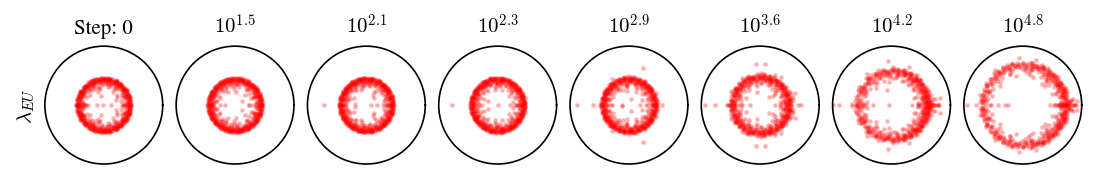

In [99]:
# Settings
matrix_steps = embedd_results['steps'][::]
ncols = len(matrix_steps)
nrows = 1
titles = [rf'$10^{{{np.log10(step):.2}}}$' for step in matrix_steps]

set_font_sizes(conf='tight')
w = 1.0
h = 0.15
double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column
width = double_w
figsize = (w*width,h*width)

# Make plots

# Make plots
# fig , axes = create_fig(nrows=1,ncols=ncols,size='double',h=0.35,sharex=False)

fig, axes = plt.subplots(ncols=ncols, nrows=1, figsize=figsize, subplot_kw={'projection': 'polar'},layout='constrained')

for i , tit in enumerate(titles):
    ax = axes[i]
    ax.set_title(f'Step: 0' if i == 0 else tit)
    eig = embedd_results['eigenvals'][i]
    x = np.real(eig)
    y = np.imag(eig)
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y,x)
    # Filter out the V-d smallest magnitudes
    idx = np.argsort(-r)[:d]
    r = r[idx]
    theta = theta[idx]
    print(r.min(),r.max(),len(r))
    
    # x_log = x * np.log10(r)/ r 
    # y_log = y * np.log10(r)/r
    # ax.scatter(x_log,y_log,s=1)
    
    ax.scatter(theta,r,s=2,color='red',alpha=0.2)
    ax.set_rscale('log')
    ax.set_thetagrids([])
    ax.set_rlim(0.01,190)
    ax.set_rticks([])
    if i == 0: ax.set_ylabel(r'$\lambda_{EU}$')
    
names = ['d','n','L','bs','lr','type_enc','sigma','amp','unmb']
params = make_params_dict(names)
save_fig(fig,'eigvals_EU',params=params,date=True)


In [100]:
# Load data statistics
dataset_size = 10000
L = 128

params = {'dataset_size': dataset_size, 'L': L}
data_stats = load_data('token_details','data_statistics',params=params,base_dir='../data')
print(data_stats.keys())

File token_details_L128_dataset_size10000.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/data_statistics
dict_keys(['unsorted_token_counts', 'sorted_token_counts', 'sorted_tokens', 'entropies_per_position', 'total_entropy', 'sorted_rank', 'bigram', 'unigram', 'conditional_bigram', 'bigram_entropy'])


In [106]:
bigram = data_stats['bigram']
unigram = data_stats['unigram']
uni_uni = np.outer(unigram,unigram)

# Where uni_uni is zero M=0 and otherwise M= (bigram - uni_uni)/uni_uni

M = np.log(bigram + 1e-12)
M.shape
# M = 1.0 * (M>0.0)
M = torch.tensor(M,device="cuda")
# SVD decomposition
# U, S, VT = torch.linalg.svd(M)
eigvals = torch.linalg.eigvals(M).cpu().numpy()/np.sqrt(d)

3.698329687455375e-79 9810.884757130241 8043


(1, 190)

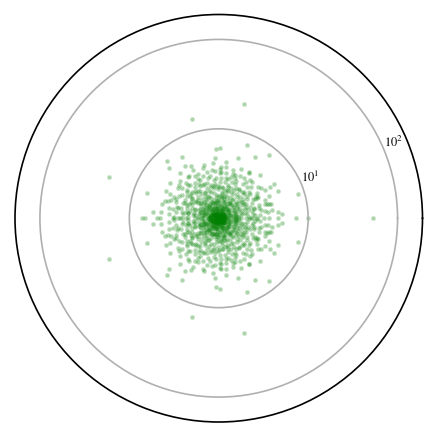

In [112]:
w = 1.0
h = 0.8
double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column
width = single_w
figsize = (w*width,h*width)

# Make plots

# Make plots
# fig , axes = create_fig(nrows=1,ncols=ncols,size='double',h=0.35,sharex=False)

fig, axes = plt.subplots(ncols=1, nrows=1, figsize=figsize, subplot_kw={'projection': 'polar'},layout='constrained')

ax = axes
x = np.real(eigvals)
y = np.imag(eigvals)
r = np.sqrt(x**2 + y**2)
theta = np.arctan2(y,x)
# Filter out the V-d smallest magnitudes
idx = np.argsort(-r)[:]
r = r[idx]
theta = theta[idx]
print(r.min(),r.max(),len(r))

# # x_log = x * np.log10(r)/ r 
# # y_log = y * np.log10(r)/r
# # ax.scatter(x_log,y_log,s=1)

ax.scatter(theta,r,s=2,color='green',alpha=0.2)
ax.set_rscale('log')
ax.set_thetagrids([])
ax.set_rlim(1,190)
# ax.set_rticks([])
# if i == 0: ax.set_ylabel(r'$\lambda_{EU}$')

# Matrix evolutions

In [205]:
# Fixed Model Parameters
d = 512
dataset_size = 10000
L = 128
rank = None
batch_size = 64

bs = batch_size
n = dataset_size

# Architectural Parameters
skip_residual = False
fr_emb = False
fr_att = False

# Hyperparameters
beta = 1.0
lr = 0.05

# Loop over various configurations  =  amp, type_enc,  unmb
sigma = 0.5
amp = 1.0
type_enc = 'learned'
unmb = True
get_every =  3


fix_names = ['rank','d','L','dataset_size','skip_residual','fr_att','fr_emb','batch_size','lr','beta']
var_names = ['type_enc','amp','unmb','sigma']
params = make_params_dict(fix_names , var_names)


summary_matrices = load_data('summary_log',experiment_name='new_evolution_matrices', params=params)


print('In scalar summary:')
for key in summary_matrices.keys():
    if key != 'tokens' and key != 'tokens_attended' and key != 'special_batch':
        summary_matrices[key] = summary_matrices[key][::get_every]
        print(f'{key}: {summary_matrices[key].shape}')

V = summary_matrices['embeddings'][0].shape[0]
ncols = len(summary_matrices['matrix_steps'])
bins = 40

results = {
    'EET_eigvals': [],
    'ETE_eigvals': [],
    'EUT_eigvals': [],
}
results['steps'] = summary_matrices['matrix_steps']
for i in range(ncols):
    print(i)
    E = torch.tensor(summary_matrices['embeddings'][i],device="cuda") # (V,d)
    dotE = E @ E.T/d  # (V,V)
    results['EET_eigvals'].append(torch.linalg.eigvalsh(dotE).cpu().numpy())
    dotE = E.T @ E / V  # (d,d)
    results['ETE_eigvals'].append(torch.linalg.eigvalsh(dotE).cpu().numpy())
    U = torch.tensor(summary_matrices['U'][i],device="cuda")  # (V,d)
    dotEU = E @ U / d  # (V,V)
    results['EUT_eigvals'].append(torch.linalg.eigvals(dotEU).cpu().numpy())

File summary_log_amp1_sigma0.5_type_enclearned_unmbTrue.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_evolution_matrices/L128_batch_size64_beta1_d512_dataset_size10000_fr_attFalse_fr_embFalse_lr0.05_rankNone_skip_residualFalse
In scalar summary:
matrix_steps: (8,)
A: (8, 3, 128, 128)
x: (8, 3, 128, 512)
e: (8, 3, 128, 512)
embeddings: (8, 8043, 512)
embedd_grad_norms: (8, 8043)
W: (8, 512, 512)
p: (8, 1, 128, 512)
U: (8, 512, 8043)
0
1
2
3
4
5
6
7


In [163]:
def lambda_lim(n,m,sigma=1.0):
    """Compute the Marchenko-Pastur distribution limits.
    X is an (m,n) random matrix with i.i.d. entries with variance sigma^2.
    C = (1/n) X X^T has eigenvalues distributed according to the Marchenko-Pastur law
    """
    q = m / n
    lambda_min = sigma**2 * (1 - np.sqrt(q))**2
    lambda_max = sigma**2 * (1 + np.sqrt(q))**2
    return lambda_min, lambda_max , q


def MP_distribution(n,m, sigma=1.0, num_points=100):
    """Compute the Marchenko-Pastur distribution."""
    lambda_min, lambda_max , q = lambda_lim(n,m,sigma)
    lambda_vals = np.linspace(0, lambda_max, num_points)
    mp_density = np.sqrt((lambda_max - lambda_vals) * (lambda_vals - lambda_min)) / (2 * np.pi *sigma**2 * q * lambda_vals)
    mp_density = np.nan_to_num(mp_density)  # Replace NaNs with zeros
    # dl = lambda_vals[1] - lambda_vals[0]
    if q > 1.0:
        # mp_density *= 1/q
        mp_density[0] = (1 - 1/q)
    return lambda_vals, mp_density

/tmp/ipykernel_1135995/10190423.py:16: RuntimeWarning: invalid value encountered in sqrt
  mp_density = np.sqrt((lambda_max - lambda_vals) * (lambda_vals - lambda_min)) / (2 * np.pi *sigma**2 * q * lambda_vals)


(8043, 512)
(8043, 512)
(8043, 512)
(8043, 512)
(8043, 512)
(8043, 512)
(8043, 512)
(8043, 512)


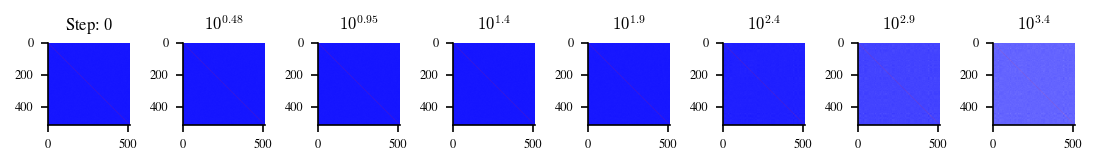

In [218]:
# Setup and variables
steps = summary_matrices['matrix_steps']
ncols = len(steps)


MP_dist = [MP_distribution(d,V,sigma=sigma,num_points=100),
            MP_distribution(V,d,sigma=sigma,num_points=100)]  

set_font_sizes(conf='tight')
# Create figure
fig , axes = create_fig(ncols=ncols,nrows=1,size='double',h=0.2,sharex=False)


for i in range(ncols):
    ax = axes[i]
    # ax.set_yscale('log')
    exp = np.log10(steps[i]) if i>0 else None
    ax.set_title(rf'$10^{{{exp:.2}}}$' if i>0 else r'Step: $0$', fontsize=FONTSIZES['s'])

    p = summary_matrices['embeddings'][i]
    print(p.shape)
    ax.imshow(p.T@p,cmap='bwr')

    # eivals = results['EUT_eigvals'][i]
    # ax.scatter(eivals.real, eivals.imag, color='purple', s=2, alpha=0.5, label='E U^T eigenvalues')

In [175]:
np.log(1)

np.float64(0.0)

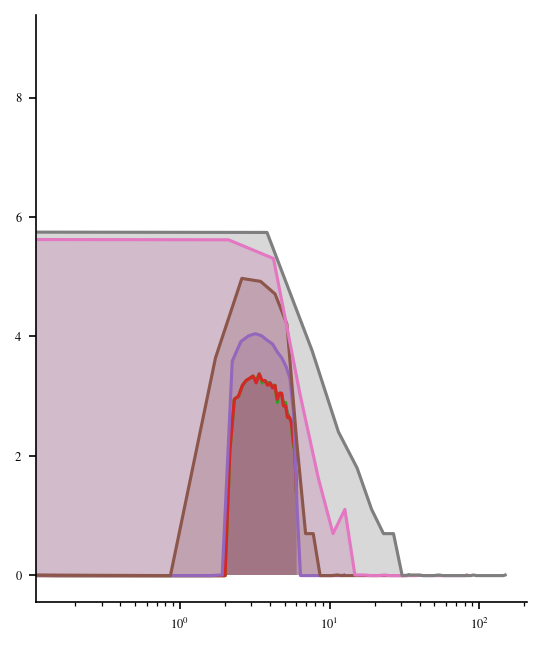

In [161]:
# 
fig , axes = create_fig(ncols=1,nrows=1,size='single',h=1.2)

ax = axes
for i in range(ncols):
    hist, edges = results['EET_eigvals'][i][0].copy(), results['EET_eigvals'][i][1].copy()
    hist[hist==0] = 0.99
    # print(hist)
    var = np.log(hist)
    ax.set_xscale('log')
    # print(var)
    # print(hist)
    ax.plot(edges,var)
    ax.fill_between(edges,0,var,alpha=0.3)
    # ax.bar(edges, np.log10(hist))

In [198]:
# Load data statistics
dataset_size = 10000
L = 128

params = {'dataset_size': dataset_size, 'L': L}
data_stats = load_data('token_details','data_statistics',params=params,base_dir='../data')
bigram = data_stats['bigram']
unigram = data_stats['unigram']
uni_uni = np.outer(unigram,unigram)

# Where uni_uni is zero M=0 and otherwise M= (bigram - uni_uni)/uni_uni
M = np.where(uni_uni==0, 0, (bigram / uni_uni))
M = np.log(M + 1e-12)
M = 1.0 * (M>0.0)
M = torch.tensor(M[:,:],device="cuda")
# SVD decomposition
U, S, VT = torch.linalg.svd(M)

File token_details_L128_dataset_size10000.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/data_statistics


/tmp/ipykernel_1135995/2632099506.py:12: RuntimeWarning: divide by zero encountered in divide
  M = np.where(uni_uni==0, 0, (bigram / uni_uni))
/tmp/ipykernel_1135995/2632099506.py:12: RuntimeWarning: invalid value encountered in divide
  M = np.where(uni_uni==0, 0, (bigram / uni_uni))


In [200]:
s = S.cpu().numpy()

In [197]:
print(np.sum(M==0))
print(np.sum(M>0))

64564543
125306


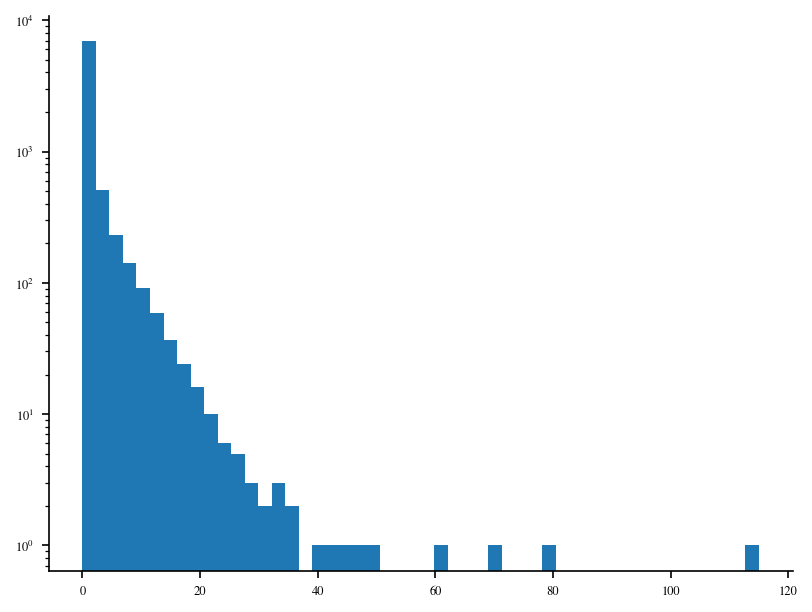

In [202]:
plt.hist(s,bins=50)
# plt.colorbar()
plt.yscale('log')
plt.show()


In [148]:
np.sort(np.abs(eival[1:]))[::-1]

array([1.28707860e+02, 1.24856187e+02, 9.48018461e+01, ...,
       5.40321532e-64, 5.22648242e-64, 4.17126156e-64], shape=(8041,))

[]

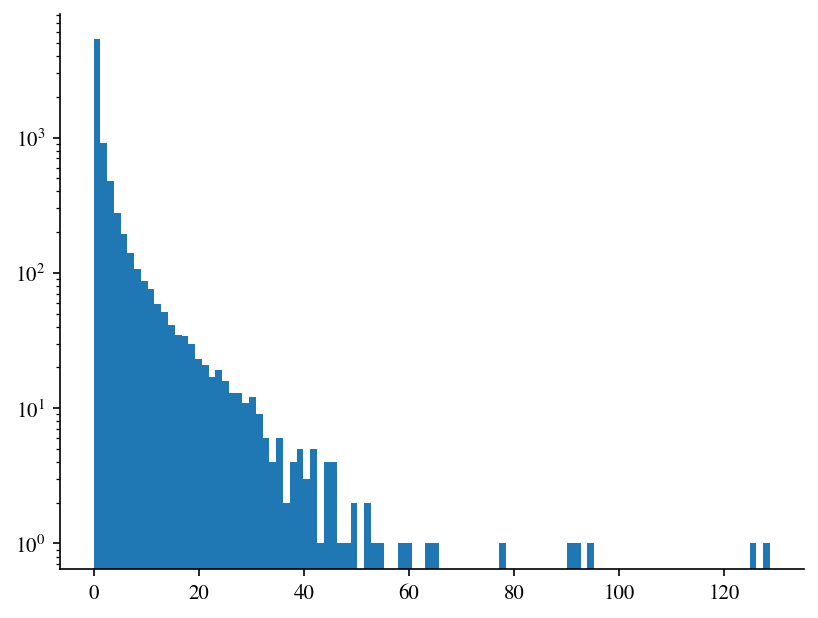

In [145]:
plt.hist(np.abs(eival[1:]),bins=100)
plt.yscale('log')
plt.plot()

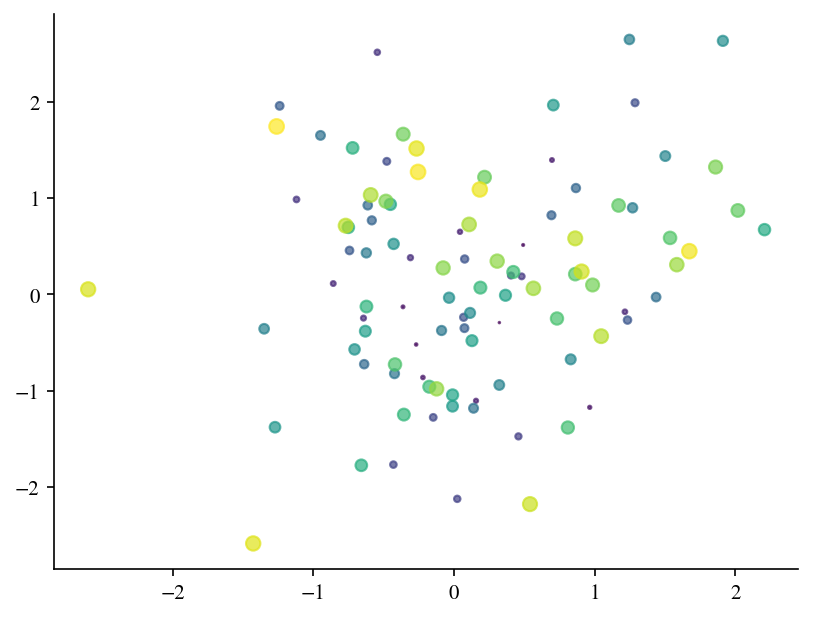

In [155]:
x = np.random.randn(100)
y = np.random.randn(100)
sizes = np.linspace(0,50,100)
colors = plt.get_cmap('viridis')(np.linspace(0,1,100))
plt.scatter(x, y, s=sizes, c=colors, alpha=0.7)

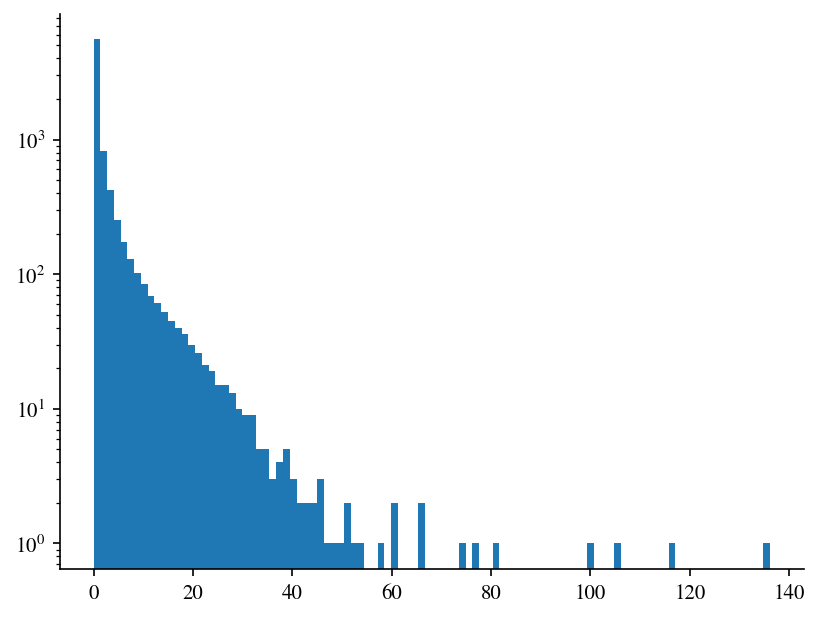

In [137]:
s = S.cpu().numpy()
plt.hist(s[1:], bins=100)
plt.yscale('log')
plt.show()

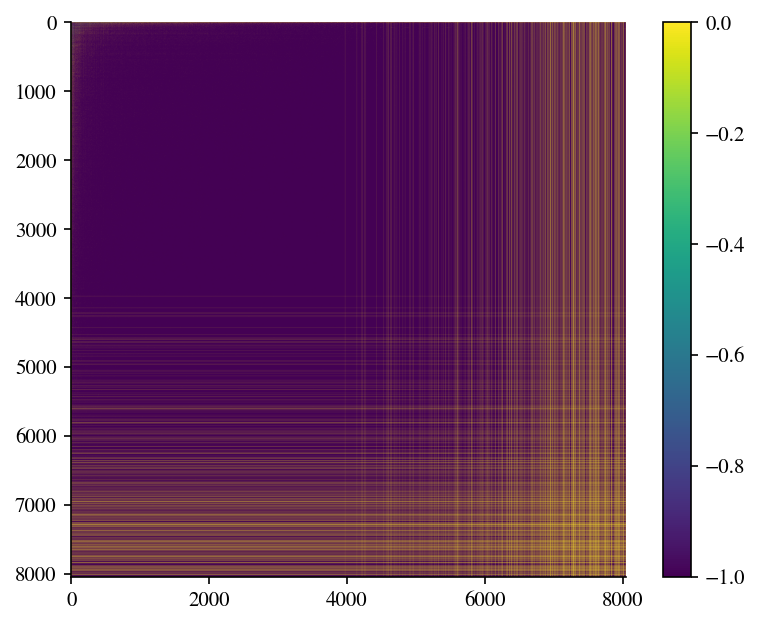

In [128]:
plt.imshow(M,vmax=0.)
plt.colorbar()

In [122]:
eigvals = torch.linalg.eigvals(M).cpu().numpy()

[]

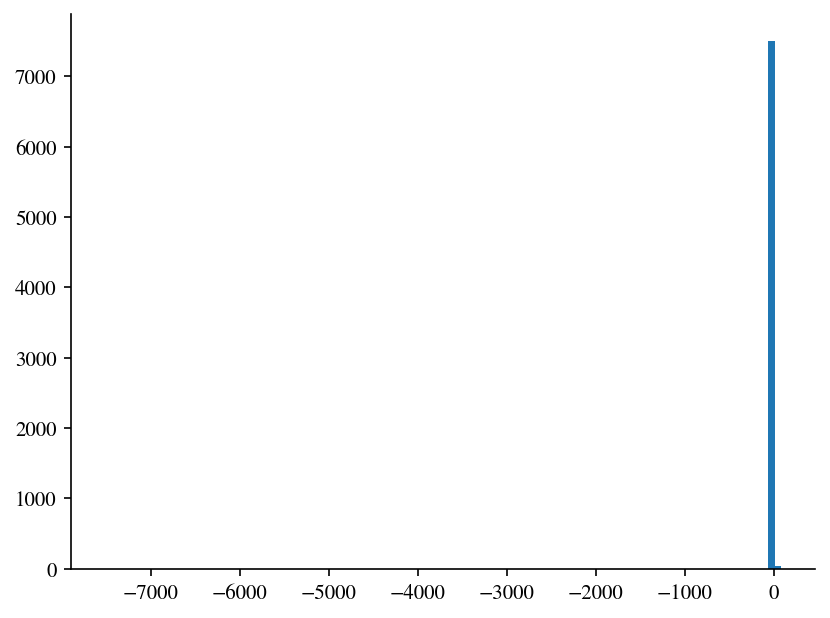

In [124]:
plt.hist(eigvals[np.abs(eigvals)>00], bins=100)
plt.plot()
# plt.yscale('log')

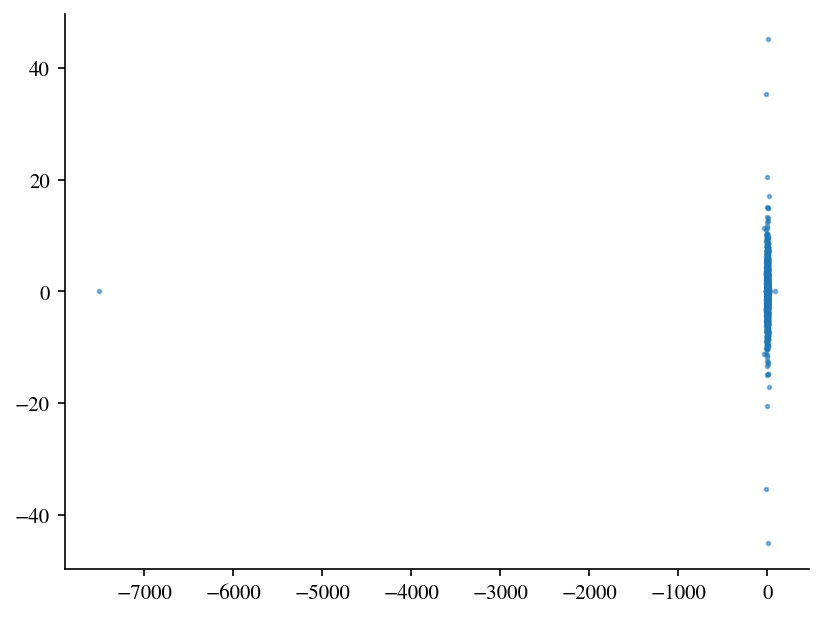

In [125]:
plt.scatter(np.real(eigvals), np.imag(eigvals),s=3,alpha=0.5)

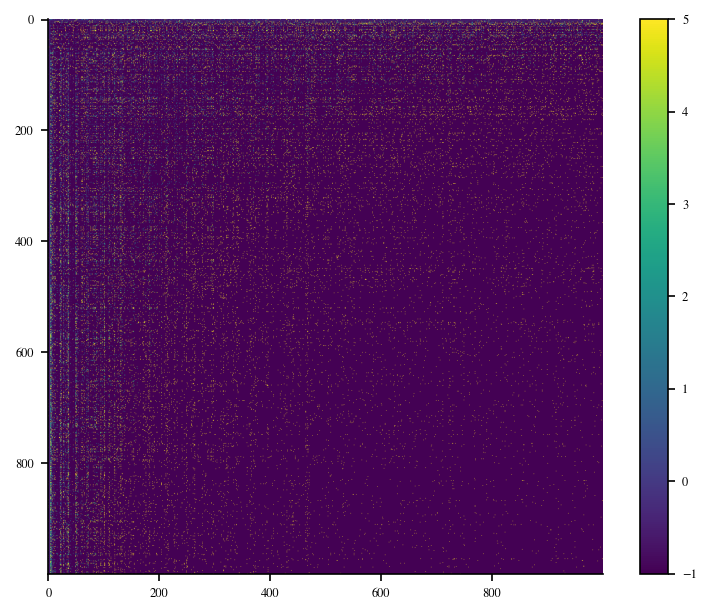

In [96]:
plt.imshow(M[:1000,:1000],vmax=5)
plt.colorbar()